Precisión en el conjunto de prueba: 0.85


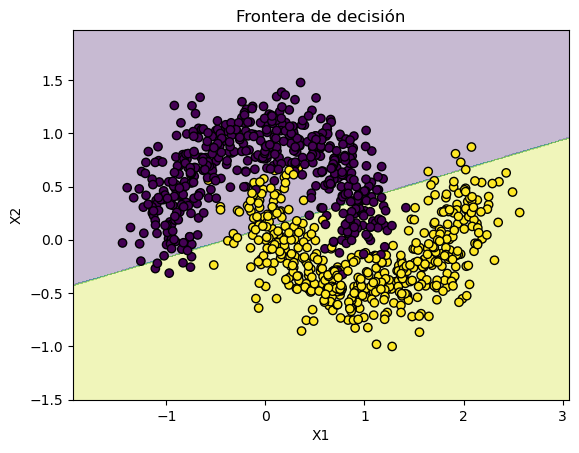

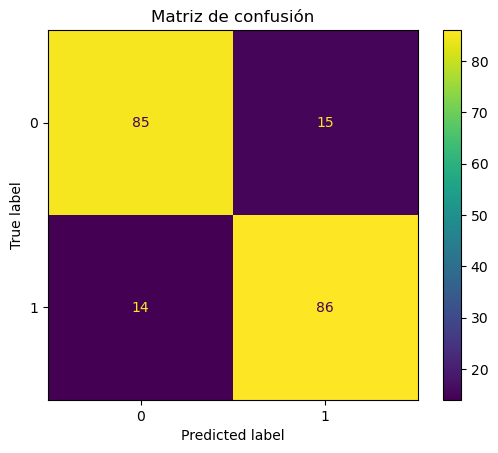

In [13]:
# Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Parte 1: Cargar datos make_moons
# Genera un conjunto de datos no lineal en forma de lunas entrelazadas, útil para clasificación binaria
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Parte 2: Dividir en entrenamiento y prueba
# Se divide el conjunto de datos en un 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parte 3: Crear el modelo
# Se crea una red neuronal con 2 capas ocultas (10 y 5 neuronas)
# Se usa la función de activación ReLU, el optimizador Adam y una tasa de aprendizaje inicial de 0.01
modelo = MLPClassifier(hidden_layer_sizes=(5), activation='logistic',
                       solver='adam', learning_rate_init=0.01,
                       max_iter=1000, random_state=42)

# Parte 4: Entrenar el modelo
# Se entrena la red neuronal con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Evaluar el modelo
# Se predicen las etiquetas del conjunto de prueba
y_pred = modelo.predict(X_test)

# Se calcula la precisión comparando las etiquetas reales con las predichas
precision = accuracy_score(y_test, y_pred)
print(f'Precisión en el conjunto de prueba: {precision:.2f}')

# Parte 5: Mostrar frontera de decisión
# Función para visualizar gráficamente cómo el modelo separa las clases
def plot_decision_boundary(model, X, y):
    h = 0.01  # resolución de la malla
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predice la clase para cada punto de la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Se grafica la región de decisión y los puntos del conjunto de datos
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title('Frontera de decisión')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()

# Llamada a la función para mostrar la frontera de decisión
plot_decision_boundary(modelo, X, y)

# También se puede graficar la matriz de confusión
# Se calcula la matriz de confusión entre las etiquetas reales y las predichas
cm = confusion_matrix(y_test, y_pred)

# Se muestra la matriz de confusión gráficamente
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión")
plt.show()